# 06 — Feature Extraction

Extracts the full window-level feature table from filtered IMU signals.

## Physical setup

| Axis | Direction | Gyro |
|------|-----------|------|
| x    | left / right (lateral)     | gx = pitch |
| y    | up / down (vertical)       | gy = yaw   |
| z    | front / back (longitudinal)| gz = roll  |

**Gravity:** `ay` ≈ −1.0 g at rest. The per-window DC mean is subtracted from **all three** accelerometer axes before any feature computation.

## Terrain classes
`dry_dirt_track` | `grass` | `muddy_dirt_track` | `smooth_terrain` | `footpath`

## Output
`data/processed/window_features.csv`

---
**Depends on:** `04_cleaning`, `04b_filtering`, `05_windowing`  
**Feeds into:** `06b_extended_features.ipynb`

## Cell 1 — Imports and paths

In [1]:
from pathlib import Path
import sys

import pandas as pd

# ── Project root resolution ───────────────────────────────────────────────
# Works whether the notebook is run from the project root or from notebooks/.
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import compute_window_features, get_feature_columns

# ── Config ────────────────────────────────────────────────────────────────
SAMPLE_RATE = 100          # Hz — sensor sampling frequency
VEL_COL     = "net_speed"  # velocity column in signals_df

# ── Data paths ────────────────────────────────────────────────────────────
# Use filtered data if available; fall back to cleaned.
filtered_path = PROJECT_ROOT / "data" / "interim" / "filtered" / "filtered_dataset.csv"
cleaned_path  = PROJECT_ROOT / "data" / "interim" / "cleaned"  / "cleaned_dataset.csv"
windows_path  = PROJECT_ROOT / "data" / "processed" / "windowed_metadata.csv"

signal_path = filtered_path if filtered_path.exists() else cleaned_path

if not signal_path.exists():
    raise FileNotFoundError(
        f"No source signal dataset found. "
        f"Expected one of:\n  {filtered_path}\n  {cleaned_path}"
    )
if not windows_path.exists():
    raise FileNotFoundError(
        f"Window metadata not found: {windows_path}\n"
        "Run 05_windowing.ipynb first."
    )

# ── Load data ─────────────────────────────────────────────────────────────
signals_df = (
    pd.read_csv(signal_path, low_memory=False)
    .sort_values(["run_id", "t_rel"])
    .reset_index(drop=True)
)
windows_df = pd.read_csv(windows_path, low_memory=False)

print(f"Signal source  : {signal_path.name}")
print(f"Signals shape  : {signals_df.shape}")
print(f"Windows shape  : {windows_df.shape}")
print(f"Velocity col   : {VEL_COL!r}  —  present in signals: {VEL_COL in signals_df.columns}")
print(f"\nSignal columns : {list(signals_df.columns)}")
print(f"\nLabel counts in signals_df:")
print(signals_df["label"].value_counts().sort_index().to_string())

Signal source  : filtered_dataset.csv
Signals shape  : (298004, 14)
Windows shape  : (2346, 9)
Velocity col   : 'net_speed'  —  present in signals: True

Signal columns : ['t', 't_rel', 'run_id', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'v1', 'v2', 'label', 'net_speed', 'yaw_rate']

Label counts in signals_df:
label
cobbelstone         56423
dry_dirt_track      79555
grass               66618
muddy_dirt_track    18972
smooth_terrain      76436


## Cell 2 — Feature extraction

`compute_window_features()` computes, for every 2-second window:

**Per axis** (ax, ay, az, gx, gy, gz) **and magnitude** (acc_mag, gyro_mag):
- Time domain: mean, std, min, max, range, median, IQR, skewness, kurtosis, ZCR, RMS, energy, mean_abs
- Spectral: total energy, dominant frequency, spectral centroid, spectral entropy
- Band-power: 1–5 Hz, 5–20 Hz, 20–40 Hz, 40–80 Hz
- Hjorth: activity, mobility, complexity
- Jerk RMS

**Correlations:**
- Within accelerometer (xy, xz, yz) and within gyroscope (xy, xz, yz)
- Cross-sensor: ay×gx, ay×gz, az×gx, ax×gz

**Odometry:**
- mean speed, speed std, distance

**Gravity removal:** per-window DC mean subtracted from ax, ay, az.

In [2]:
features_df = compute_window_features(
    windows_df  = windows_df,
    signals_df  = signals_df,
    sample_rate = SAMPLE_RATE,
    vel_col     = VEL_COL,   # set to None if no odometry
)

ID_COLS      = ["window_id", "run_id", "segment_id", "label", "t_start", "t_end", "n_samples"]
feature_cols = get_feature_columns(features_df, id_cols=ID_COLS)

print(f"Features shape : {features_df.shape}")
print(f"Feature count  : {len(feature_cols)}")
print(f"\nFeature column sample (first 20):")
print(feature_cols[:20])
print(f"\nLabel distribution in features_df:")
print(features_df["label"].value_counts().sort_index().to_string())

Features shape : (2346, 220)
Feature count  : 213

Feature column sample (first 20):
['ax_mean', 'ax_std', 'ax_min', 'ax_max', 'ax_range', 'ax_median', 'ax_iqr', 'ax_skewness', 'ax_kurtosis', 'ax_zero_crossing_rate', 'ax_rms', 'ax_energy', 'ax_mean_abs', 'ax_spectral_energy', 'ax_dominant_freq', 'ax_spectral_centroid', 'ax_spectral_entropy', 'ax_bandpower_1_5Hz', 'ax_bandpower_5_20Hz', 'ax_bandpower_20_40Hz']

Label distribution in features_df:
label
cobbelstone         355
dry_dirt_track      652
grass               488
muddy_dirt_track    145
smooth_terrain      706


## Cell 3 — Sanity check: key features by terrain class

A quick per-class mean of the most terrain-discriminative features.  
Expect:
- `acc_mag_rms` and `acc_mag_std` to be **highest** on `muddy_dirt_track` (wheel slip, sinkage vibration)
- `gyro_mag_rms` to be **lowest** on `smooth_terrain`
- `cross_ay_gx` (vertical bounce × pitch) to differ clearly between mud and grass

In [3]:
CHECK_COLS = [
    c for c in [
        "acc_mag_rms",
        "acc_mag_std",
        "gyro_mag_rms",
        "ay_jerk_rms",    # vertical jerk — terrain roughness
        "gz_jerk_rms",    # roll jerk — side-to-side instability
        "cross_ay_gx",    # vertical bounce × pitch
        "cross_ay_gz",    # vertical bounce × roll
        "odom_mean_speed",
    ] if c in features_df.columns
]

print("Per-class feature means:")
print(features_df.groupby("label")[CHECK_COLS].mean().round(4).to_string())

Per-class feature means:
                  acc_mag_rms  acc_mag_std  gyro_mag_rms  ay_jerk_rms  gz_jerk_rms  cross_ay_gx  cross_ay_gz  odom_mean_speed
label                                                                                                                        
cobbelstone            0.2590       0.1135       12.2751       9.7973     205.2919      -0.0552       0.0402           0.7452
dry_dirt_track         0.1544       0.0685       11.9358       5.5154     123.9640      -0.0557       0.0198           0.7269
grass                  0.1374       0.0588       12.0490       3.4085     110.3678      -0.0758       0.1184           0.5859
muddy_dirt_track       0.1589       0.0741       11.3092       5.6085      95.2156      -0.0755       0.0604           0.7871
smooth_terrain         0.1519       0.0690       10.6522       5.5711      88.7366      -0.0104      -0.0507           1.1243


## Cell 4 — Save to disk

In [4]:
output_path = PROJECT_ROOT / "data" / "processed" / "window_features.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
features_df.to_csv(output_path, index=False)

print(f"Saved → {output_path}")
print(f"Shape : {features_df.shape}")

Saved → /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/processed/window_features.csv
Shape : (2346, 220)


## Cell 5 — Basic EDA

Distribution plots and correlation heatmap on a curated feature subset.  
Full EDA (including t-SNE, mutual information, velocity splitting) is in **06b**.

In [5]:
from src.features import (
    get_eda_feature_columns,
    print_feature_diagnostics,
    plot_feature_distributions,
    plot_correlation_heatmap,
)

reports_dir  = PROJECT_ROOT / "reports" / "features" / "dataset_A"
eda_feat_cols = get_eda_feature_columns(features_df, id_cols=ID_COLS)

print(f"Total features       : {len(feature_cols)}")
print(f"EDA feature subset   : {len(eda_feat_cols)}")

# ── Diagnostics ───────────────────────────────────────────────────────────
label_summary = print_feature_diagnostics(
    features_df,
    feature_cols=eda_feat_cols,
    label_col="label",
)

Total features       : 213
EDA feature subset   : 117
FEATURE TABLE DIAGNOSTICS
  Shape          : (2346, 220)
  Feature count  : 117
  Missing values : 0 total

  Label distribution (label):
                  count  pct_%
label                         
cobbelstone         355  15.13
dry_dirt_track      652  27.79
grass               488  20.80
muddy_dirt_track    145   6.18
smooth_terrain      706  30.09

  Per-class mean of key features:
                  acc_mag_rms  acc_mag_std  acc_mag_energy  gyro_mag_rms  gyro_mag_std  ay_jerk_rms  gz_jerk_rms  cross_ay_gx  cross_ay_gz
label                                                                                                                                     
cobbelstone            0.2590       0.1135         16.5956       12.2751        2.8141       9.7973     205.2919      -0.0552       0.0402
dry_dirt_track         0.1544       0.0685          6.5177       11.9358        1.9738       5.5154     123.9640      -0.0557       0.0198


/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


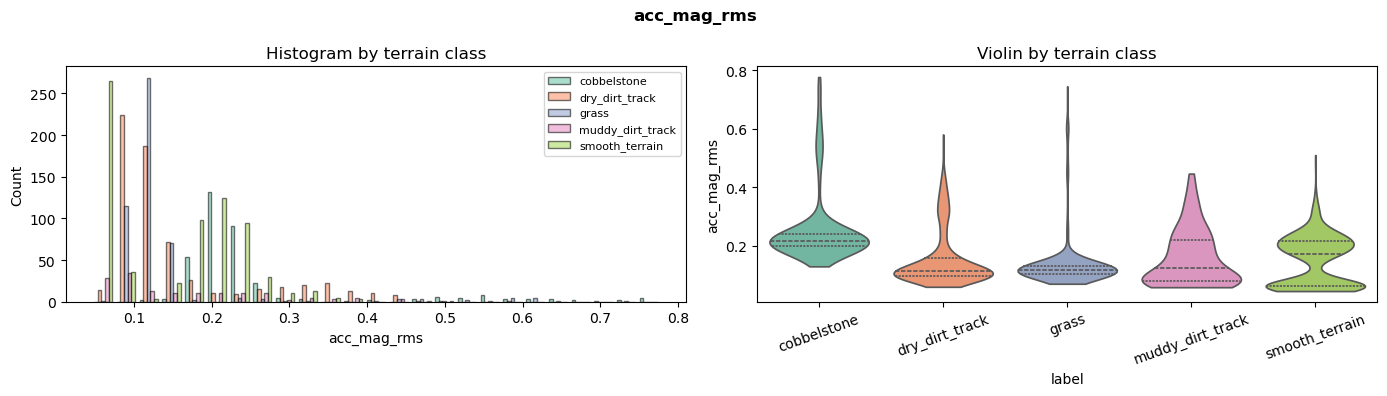

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


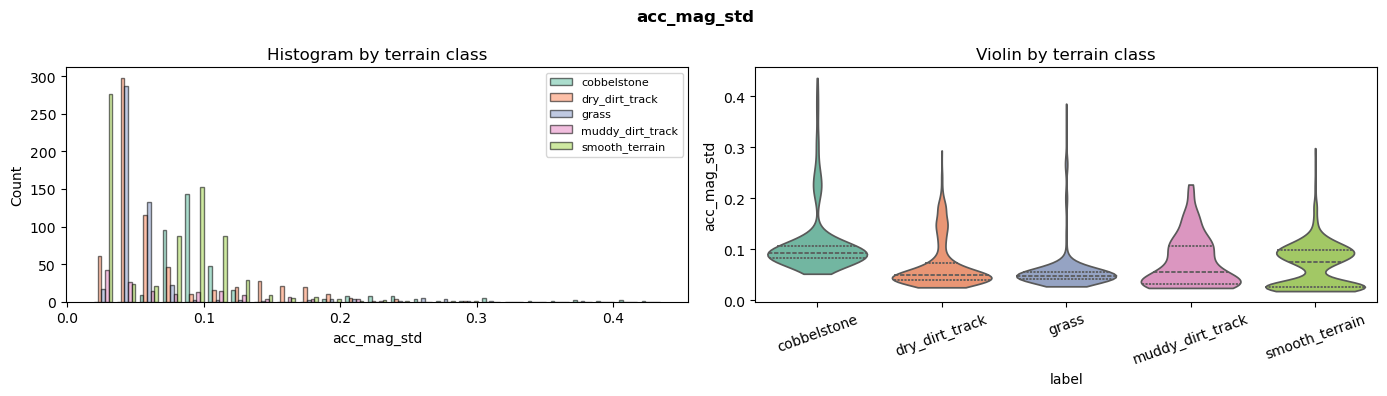

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


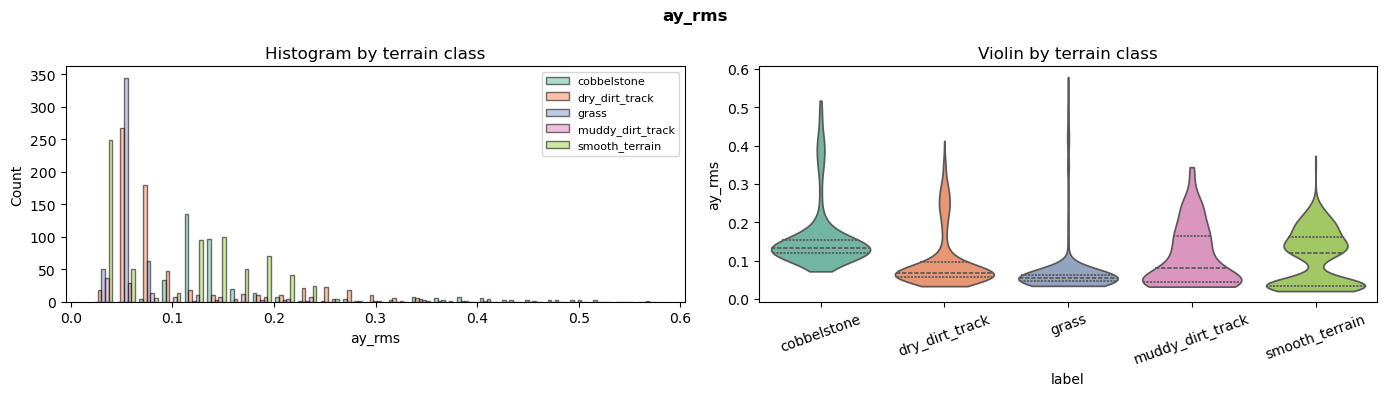

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


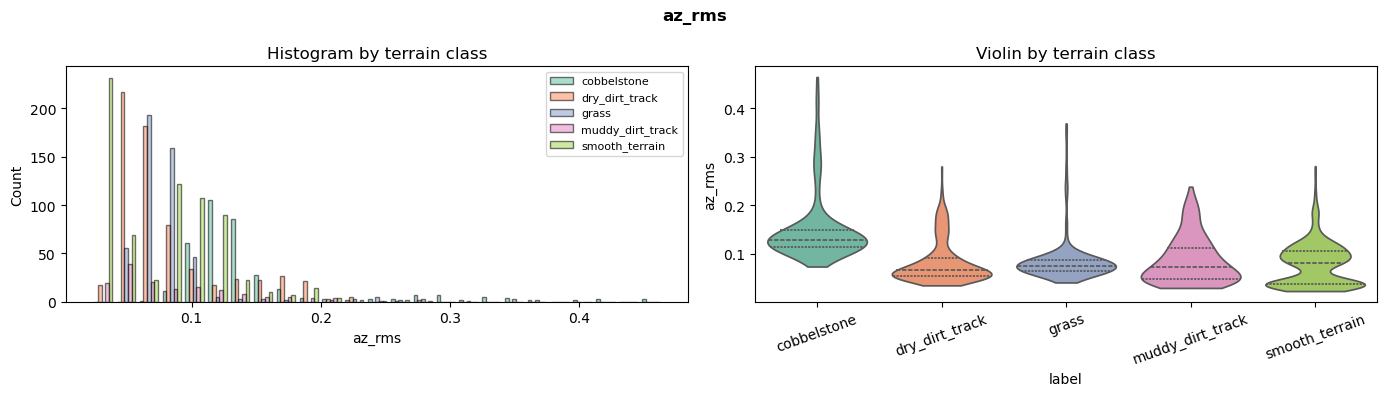

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


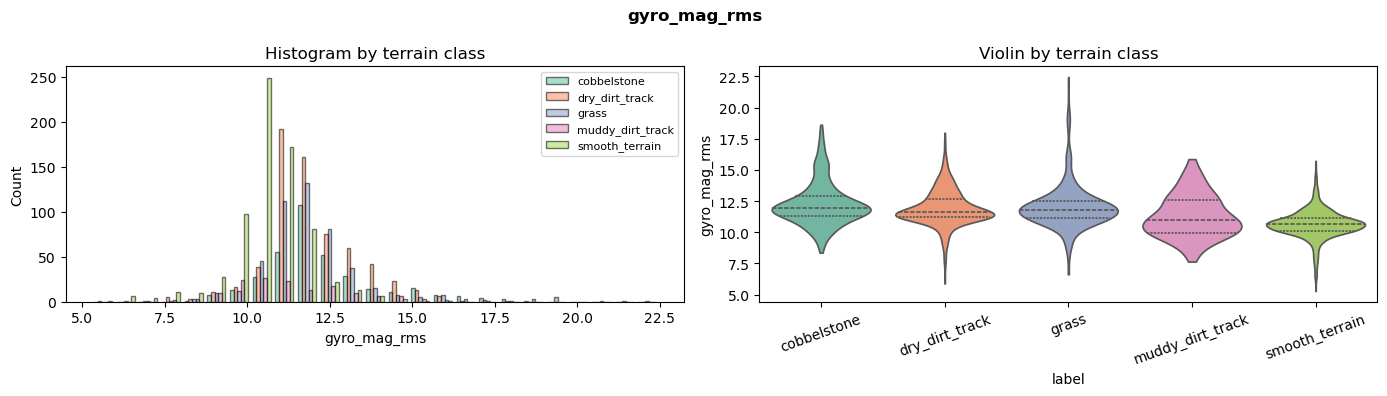

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


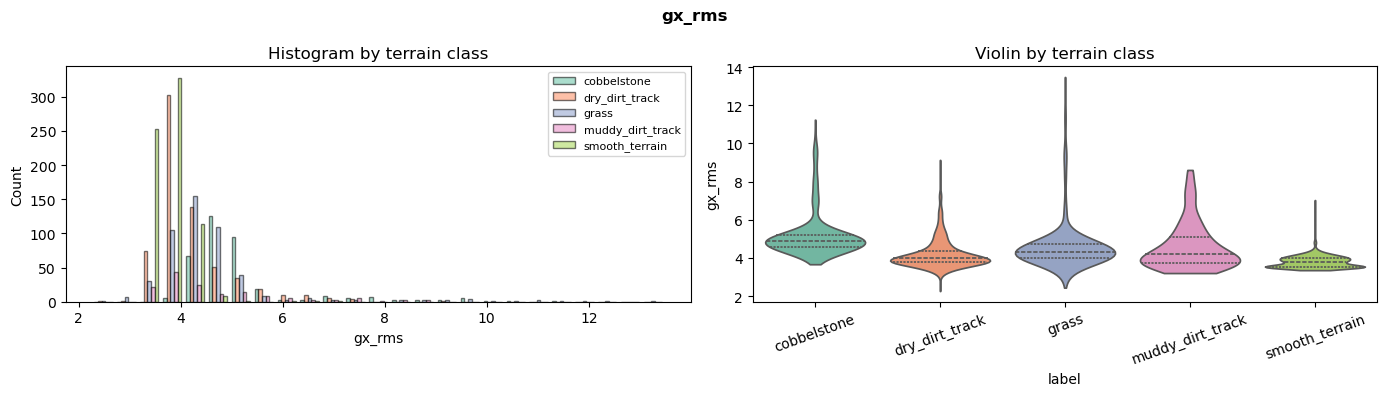

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


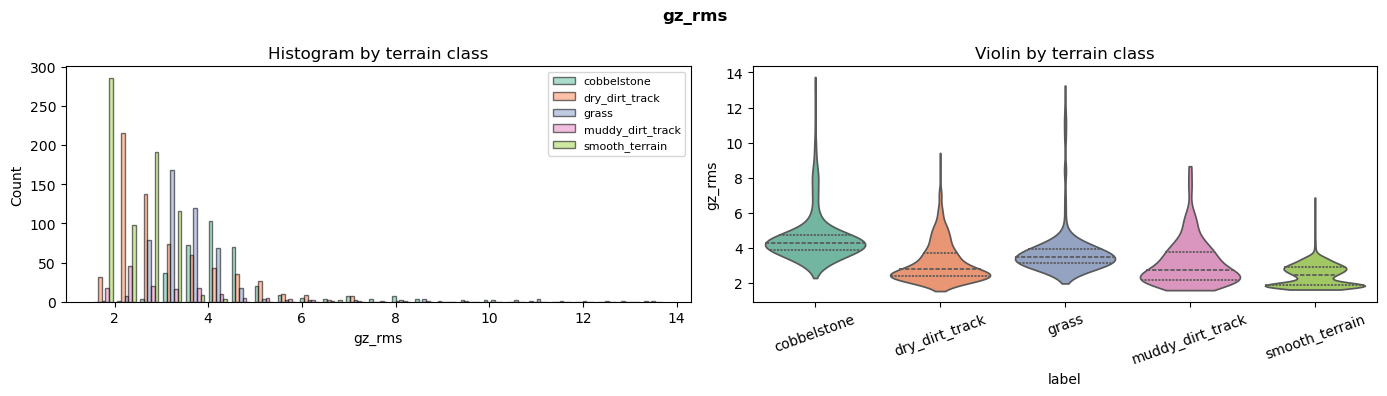

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


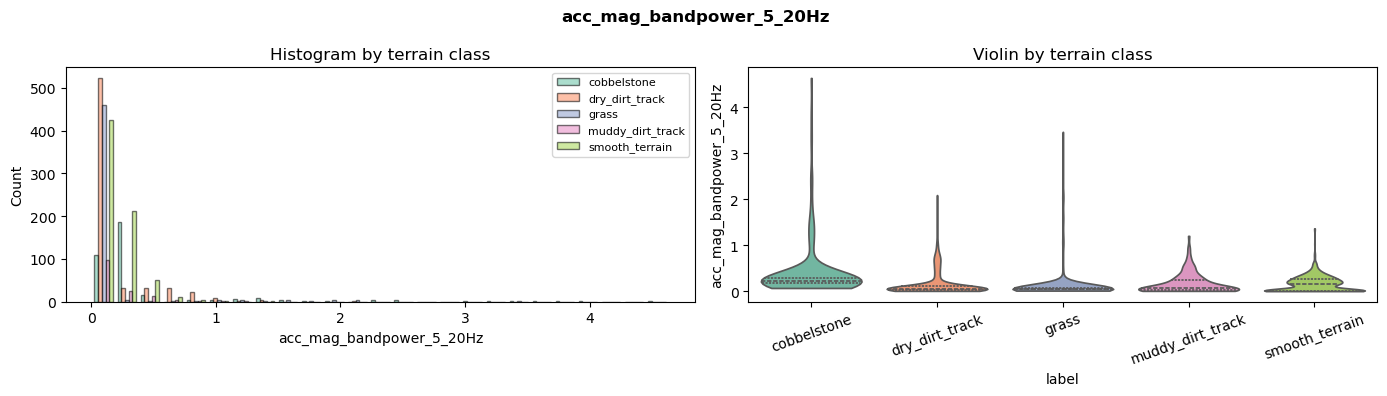

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


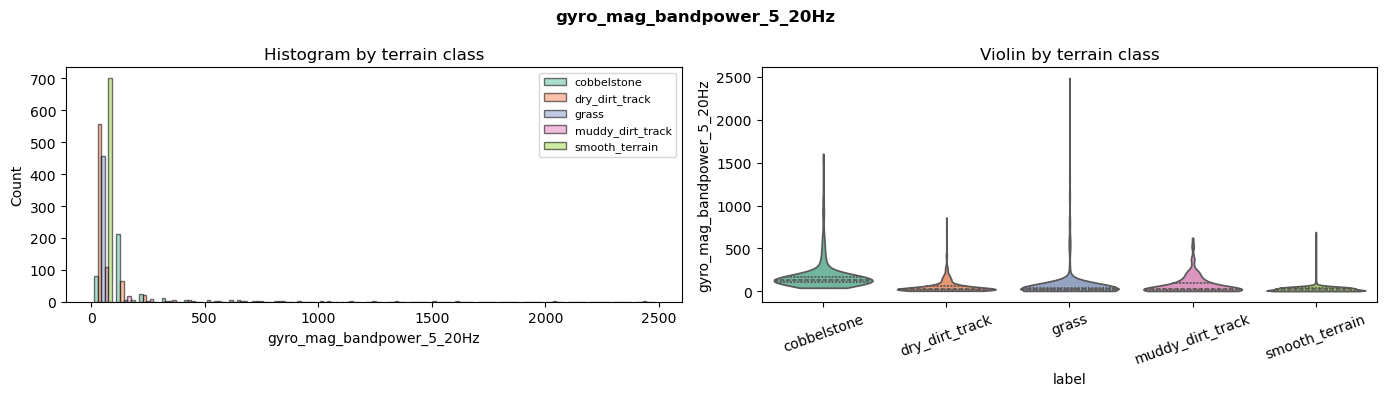

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


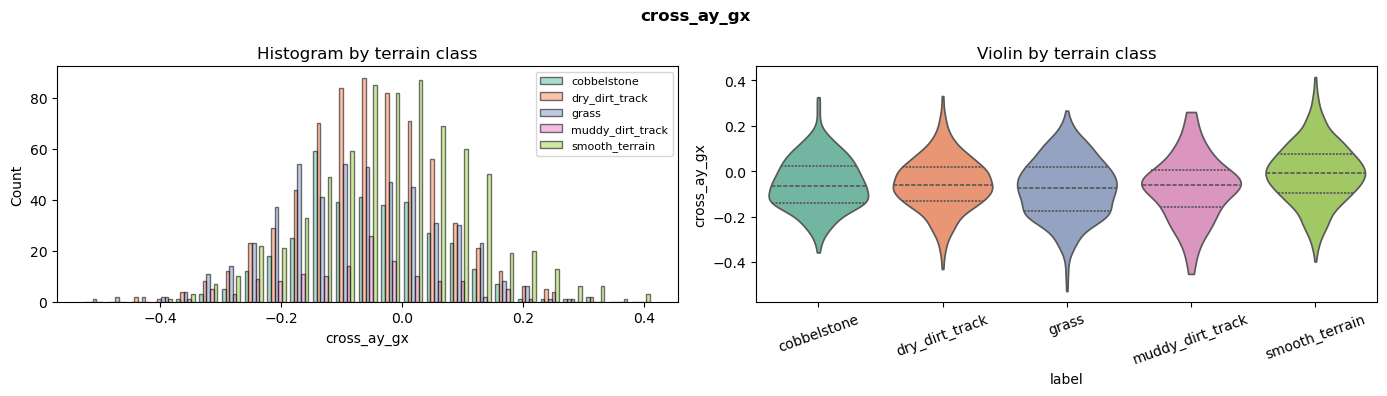

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


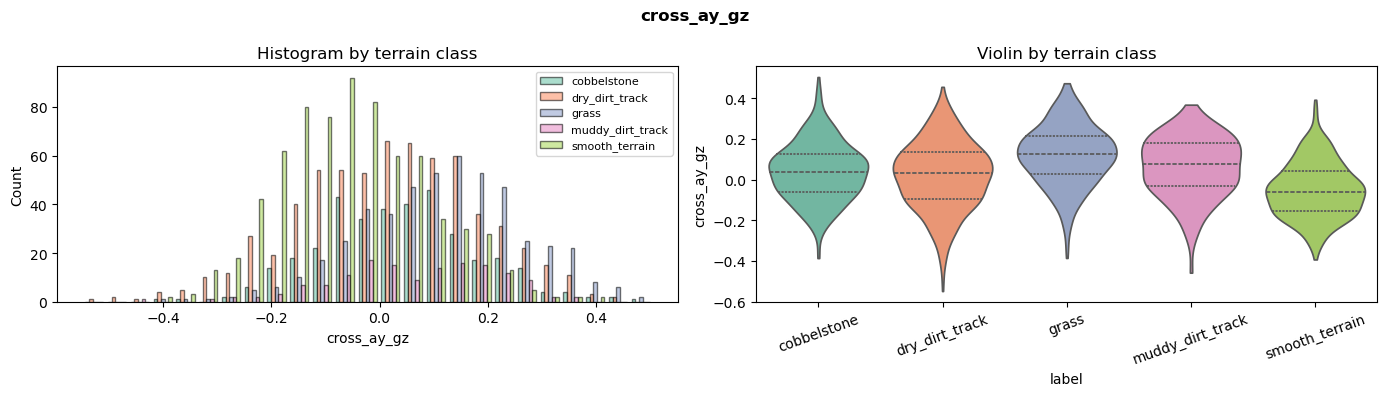

[plot_feature_distributions] Saved 11 figures → /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_A

Distribution plots saved → /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_A


In [6]:
# ── Distribution plots ────────────────────────────────────────────────────
# These 11 features are the most physically interpretable and terrain-discriminative.
# Interpretations:
#   acc_mag_rms       — overall vibration intensity
#   acc_mag_std       — vibration variability (roughness)
#   ay_rms            — vertical vibration (terrain unevenness after DC removal)
#   az_rms            — longitudinal vibration (braking / traction events)
#   gyro_mag_rms      — overall rotation rate (angular instability)
#   gx_rms            — pitch rate (nose-up/down oscillation over bumps)
#   gz_rms            — roll rate (left-right tipping on rough terrain)
#   acc_mag_bandpower_5_20Hz  — terrain texture frequency band
#   gyro_mag_bandpower_5_20Hz — rotation in the terrain-texture band
#   cross_ay_gx       — vertical bounce × pitch coupling (mud sinkage indicator)
#   cross_ay_gz       — vertical bounce × roll coupling (uneven wheel sinkage)

VIZ_FEATURES = [
    "acc_mag_rms",
    "acc_mag_std",
    "ay_rms",
    "az_rms",
    "gyro_mag_rms",
    "gx_rms",
    "gz_rms",
    "acc_mag_bandpower_5_20Hz",
    "gyro_mag_bandpower_5_20Hz",
    "cross_ay_gx",
    "cross_ay_gz",
]

dist_files = plot_feature_distributions(
    features_df  = features_df,
    viz_features = VIZ_FEATURES,
    reports_dir  = reports_dir,
    label_col    = "label",
    show         = True,
)
print(f"\nDistribution plots saved → {reports_dir}")

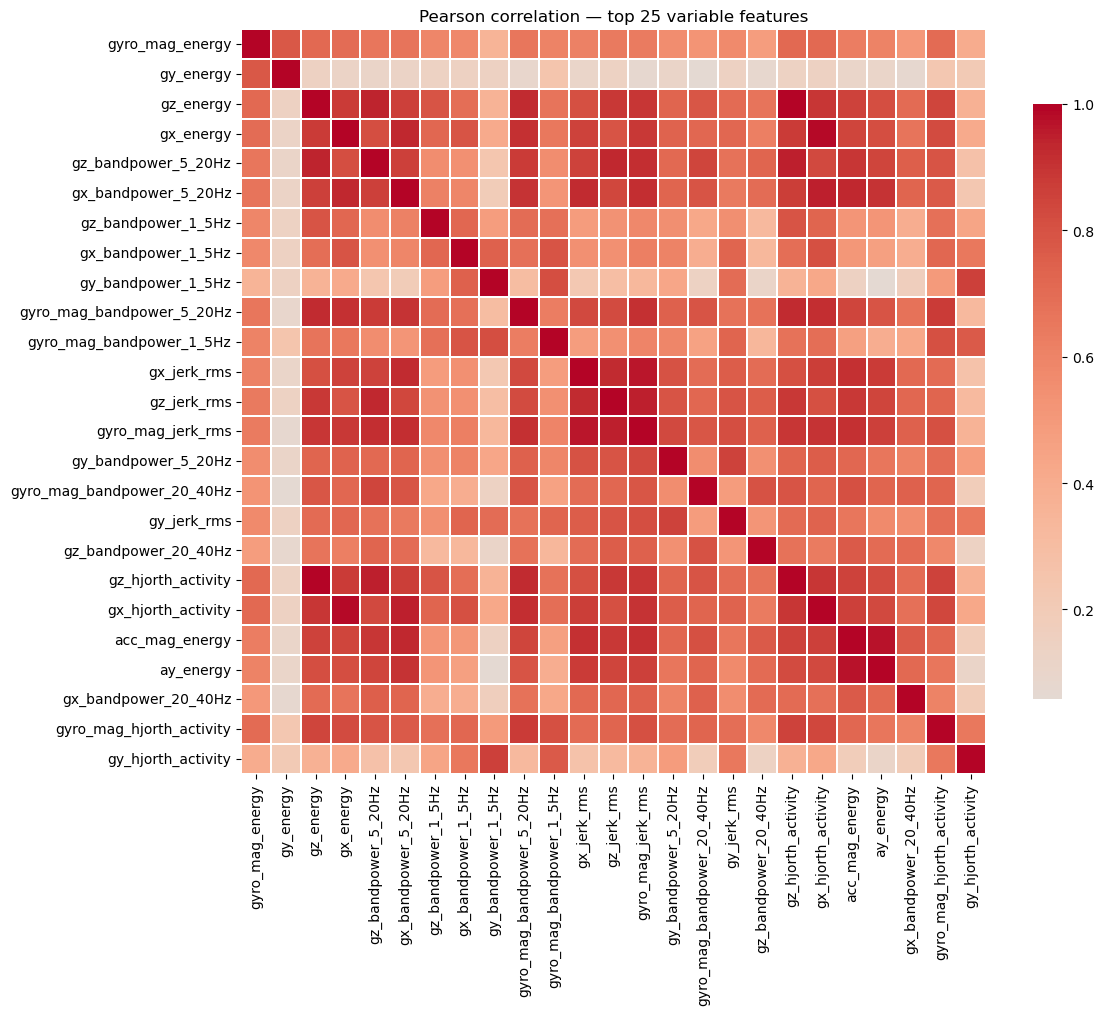


Top 15 absolute correlation pairs:
                feature_1                 feature_2     corr
                gz_energy        gz_hjorth_activity 0.995303
                gx_energy        gx_hjorth_activity 0.982373
           acc_mag_energy                 ay_energy 0.970584
              gx_jerk_rms         gyro_mag_jerk_rms 0.961953
      gx_bandpower_5_20Hz        gx_hjorth_activity 0.950570
              gz_jerk_rms         gyro_mag_jerk_rms 0.948820
      gz_bandpower_5_20Hz        gz_hjorth_activity 0.946513
                gz_energy       gz_bandpower_5_20Hz 0.940717
                gx_energy       gx_bandpower_5_20Hz 0.933996
      gz_bandpower_5_20Hz               gz_jerk_rms 0.931389
      gx_bandpower_5_20Hz            acc_mag_energy 0.926997
gyro_mag_bandpower_5_20Hz        gz_hjorth_activity 0.924113
      gx_bandpower_5_20Hz               gx_jerk_rms 0.921191
              gx_jerk_rms               gz_jerk_rms 0.919718
                gz_energy gyro_mag_bandpower_5_20

In [7]:
# ── Correlation heatmap ───────────────────────────────────────────────────
corr_pairs = plot_correlation_heatmap(
    features_df  = features_df,
    feature_cols = eda_feat_cols,
    reports_dir  = reports_dir,
    top_n        = 25,
    show         = True,
)
print(f"\nNext step → run 06b_extended_features.ipynb")